# End-to-end study — prepared representations, tuning and protected-test benchmark


## Scientific question
How much do representation choice and hyperparameter optimization change performance on a **protected external test set**? We compare two prepared representations, two classical models, untuned and tuned modes, repeated seeds, and a dummy baseline. Tuning is confined to train/validation; all reported benchmark scores come from the protected test.


In [1]:
import os
os.environ.setdefault("MPLBACKEND", "Agg")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DEMO_TEST = os.getenv("MLCORE_DEMO_TEST") == "1"

def balanced_fold_labels(y, n_splits):
    """Demo-only external memberships. Production partition generation belongs to BioSieve."""
    y = np.asarray(y)
    folds = np.empty(len(y), dtype=int)
    for label in np.unique(y):
        idx = np.flatnonzero(y == label)
        folds[idx] = np.arange(len(idx)) % n_splits
    return folds

from sklearn.datasets import make_classification
from mlcore import benchmark
from mlcore.benchmark import BenchmarkConfig
from mlcore.core import SearchSpace, Categorical
from mlcore.datasets import DatasetBundle, PartitionPlan
from mlcore.tuning import TuningConfig


In [2]:
rng=np.random.default_rng(2026)
n_samples=150 if DEMO_TEST else 360
X,y=make_classification(n_samples=n_samples,n_features=14,n_informative=9,n_redundant=2,weights=[.6,.4],class_sep=1.05,random_state=2026)
ids=np.asarray([f"study_{i:04d}" for i in range(len(y))],dtype=object)
rep_a=DatasetBundle(X=X,y=y,sample_ids=ids,feature_names=[f"A_{i}" for i in range(X.shape[1])])
rep_b_X=np.column_stack([X[:,:9],0.35*X[:,0:3]+rng.normal(scale=.4,size=(len(y),3)),rng.normal(size=(len(y),8))])
rep_b=DatasetBundle(X=rep_b_X,y=y,sample_ids=ids,feature_names=[f"B_{i}" for i in range(rep_b_X.shape[1])])
train_ids=[]; val_ids=[]; test_ids=[]
for cls in np.unique(y):
    cls_ids=ids[y==cls]; n=len(cls_ids); a,b=int(.60*n),int(.80*n)
    train_ids.extend(cls_ids[:a]); val_ids.extend(cls_ids[a:b]); test_ids.extend(cls_ids[b:])
plan=PartitionPlan.holdout(train_ids=train_ids,validation_ids=val_ids,test_ids=test_ids,dataset_fingerprint=rep_a.fingerprint,
                           metadata={"source":"prepared_holdout","test_role":"protected"})


In [3]:
seeds=(42,) if DEMO_TEST else (42,123)
tuning=TuningConfig(optimizer="grid",metrics=("mcc","roc_auc"),refit_metric="mcc",random_state=None,n_jobs=1)
search_spaces={
    "logistic_regression":SearchSpace("logreg",{"C":Categorical([0.1,1.0,3.0]),"solver":Categorical(["lbfgs"])}),
    "random_forest":SearchSpace("rf",{"n_estimators":Categorical([40,80] if DEMO_TEST else [80,160]),"max_depth":Categorical([4,8])}),
}
bench=benchmark(
    datasets={"representation_A":rep_a,"representation_B":rep_b},
    algorithms=("logistic_regression","random_forest"), partitions={"development_plus_protected_test":plan},
    config=BenchmarkConfig(metrics=("mcc","balanced_accuracy","f1","roc_auc"),seeds=seeds,modes=("untuned","tuned"),
                           include_baselines=True,tuning=tuning),
    search_spaces=search_spaces,
)
assert not bench.failures
runs=bench.runs_frame(); metrics=bench.aggregate_metrics_frame(); history=bench.optimization_history_frame(); preds=bench.predictions_frame()
leader=(metrics[metrics.metric=="mcc"].groupby(["representation","algorithm","mode"])["score"].agg(["mean","std"]).reset_index())
leader.sort_values("mean",ascending=False).head(10)


,representation,algorithm,mode,mean,std
4,representation_A,random_forest,untuned,0.537777,0.000000
3,representation_A,random_forest,tuned,0.534712,0.083817
7,representation_B,logistic_regression,untuned,0.532766,0.000000
6,representation_B,logistic_regression,tuned,0.532766,0.000000
8,representation_B,random_forest,tuned,0.462317,0.068920
1,representation_A,logistic_regression,tuned,0.453479,0.000000
9,representation_B,random_forest,untuned,0.445422,0.040198
2,representation_A,logistic_regression,untuned,0.443823,0.000000
0,representation_A,dummy_classifier,baseline,0.000000,0.000000
5,representation_B,dummy_classifier,baseline,0.000000,0.000000


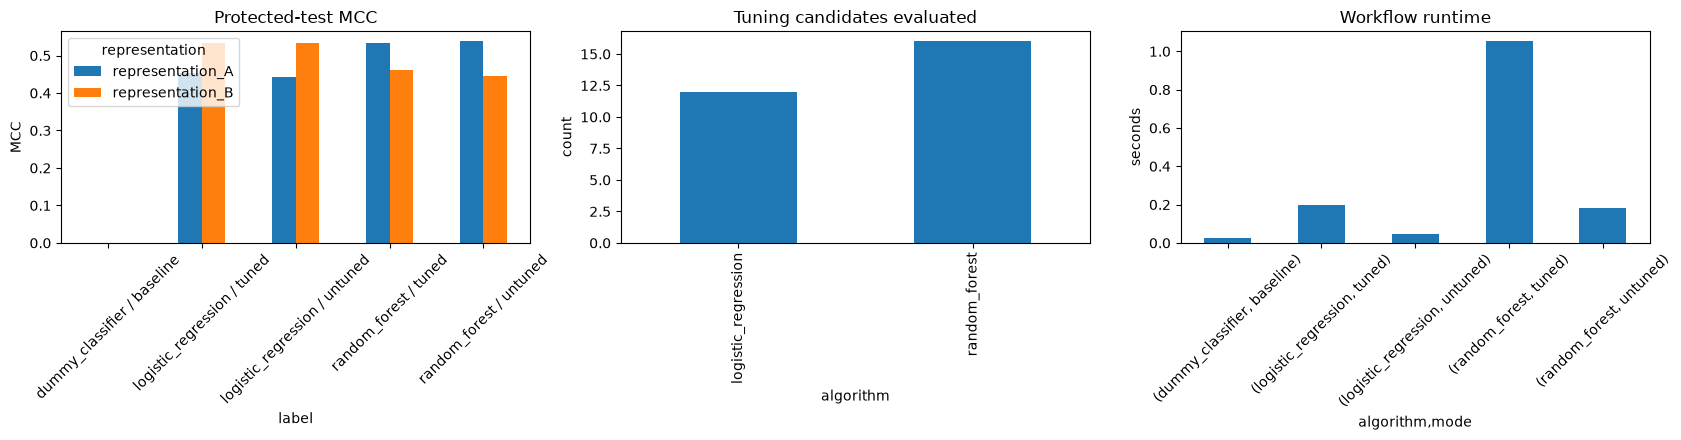

In [4]:
fig,axes=plt.subplots(1,3,figsize=(17,4.5))
plot=leader.copy(); plot["label"]=plot.algorithm+" / "+plot["mode"]
plot.pivot(index="label",columns="representation",values="mean").plot.bar(ax=axes[0]); axes[0].set(title="Protected-test MCC",ylabel="MCC"); axes[0].tick_params(axis="x",rotation=45)
if not history.empty:
    h=history[history.status=="complete"].copy(); h.groupby("algorithm").size().plot.bar(ax=axes[1]); axes[1].set(title="Tuning candidates evaluated",ylabel="count")
runs.groupby(["algorithm","mode"])["elapsed_seconds"].mean().plot.bar(ax=axes[2]); axes[2].set(title="Workflow runtime",ylabel="seconds"); axes[2].tick_params(axis="x",rotation=45)
plt.tight_layout(); FIGURE_COUNT=1


In [5]:
nonbaseline={"logistic_regression","random_forest"}
expected=len(seeds)*2*(1+2*len(nonbaseline))
DEMO_CHECKS={
    "benchmark_matrix":bench.n_runs==expected,
    "no_failures":len(bench.failures)==0,
    "tuned_runs_have_history":not history.empty,
    "protected_test_only":set(preds.evaluation_role)=={"test"},
    "all_metrics":set(metrics.metric.unique())=={"mcc","balanced_accuracy","f1","roc_auc"},
    "run_prediction_traceability":set(preds.run_id)==set(runs.run_id),
    "leaderboard_available":not leader.empty,
    "figure_created":FIGURE_COUNT==1,
}
assert all(DEMO_CHECKS.values()), DEMO_CHECKS
DEMO_CHECKS


{'benchmark_matrix': True,
 'no_failures': True,
 'tuned_runs_have_history': True,
 'protected_test_only': True,
 'all_metrics': True,
 'run_prediction_traceability': True,
 'leaderboard_available': True,
 'figure_created': True}